# Question 3 — Does 311 Adoption Change City Government Spending?

## Data coverage note
Census Individual Unit Finance files are publicly available for **2017–2022** only
(6 years). Cities that adopted 311 before 2017 appear as always-treated in the panel;
they contribute cross-sectional variation (treated vs. never-treated) but no
pre-post variation for their specific adoption year. The event study is therefore
informative only for cities that adopted 2012 or later.

## Outputs
- `results/figures/fig_event_study.png`
- `results/tables/tab_twfe.tex` + `.csv`

## Code: `pyfixest` throughout

In [1]:
import re
import io
import zipfile
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pyfixest as pf
from pathlib import Path

CLEAN   = '../data_clean/'
RAW     = '../data_raw/indFin/'
FIGURES = '../results/figures/'
TABLES  = '../results/tables/'

for p in [RAW, FIGURES, TABLES]:
    Path(p).mkdir(parents=True, exist_ok=True)

# Publication figure style
plt.rcParams.update({
    'font.family': 'sans-serif', 'font.size': 11,
    'axes.labelsize': 12, 'xtick.labelsize': 10, 'ytick.labelsize': 10,
    'axes.spines.top': False, 'axes.spines.right': False,
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'savefig.dpi': 300, 'savefig.bbox': 'tight',
})

print('pyfixest version:', pf.__version__)

pyfixest version: 0.50.1


## Step 1 — Download and parse Census Individual Unit Finance files (2017–2022)

In [2]:
# ── Fixed-width layouts (Census technical documentation, TABLES directory) ───
#
# Finance file — 32 chars per record:
#   govid[0:12]   item[12:15]   amount[15:27] ($thousands)   year[27:31]   flag[31]
#
# PID file — 146 chars per record:
#   govid[0:12]   name[12:76]   county[76:111]
#   place_fips[111:116]   population[116:125]
#   GEOID = state[0:2].zfill(2) + place_fips[111:116].zfill(5)
#   type code at position 2: '2' = municipality

YEARS         = list(range(2017, 2023))
BASE          = 'https://www2.census.gov/programs-surveys/gov-finances/tables'
CACHE_TO_DISK = False   # True = save ZIPs to data_raw/indFin/ for faster re-runs

UTIL_SUFFIXES = {'90', '91', '92', '93', '94'}
EXP_PREFIXES  = {'E', 'F', 'G'}
INTEREST_CODE = 'I89'

def is_general_expenditure(item: str) -> bool:
    item = item.strip()
    if item == INTEREST_CODE:
        return True
    if len(item) == 3 and item[0] in EXP_PREFIXES:
        return item[1:] not in UTIL_SUFFIXES
    return False

def get_file(z, patterns):
    names = z.namelist()
    for pat in patterns:
        hits = [n for n in names if pat in n]
        if hits:
            return hits[0]
    raise FileNotFoundError(f'No file matching {patterns} in {names}')

def get_zip_bytes(year: int) -> bytes:
    """Download ZIP into RAM; optionally cache to disk."""
    url        = f'{BASE}/{year}/{year}_Individual_Unit_File.zip'
    cache_path = Path(RAW) / f'{year}_Individual_Unit_File.zip'

    if CACHE_TO_DISK and cache_path.exists():
        return cache_path.read_bytes()

    print(f'  Downloading {year}...', end=' ', flush=True)
    r = requests.get(url, timeout=180)
    r.raise_for_status()
    print(f'{len(r.content)/1e6:.1f} MB', flush=True)

    if CACHE_TO_DISK:
        cache_path.write_bytes(r.content)

    return r.content   # stays in RAM; ZIP bytes released after parse_year_zip returns

def parse_year_zip(year: int):
    raw = get_zip_bytes(year)             # ~5-15 MB in RAM
    z   = zipfile.ZipFile(io.BytesIO(raw))

    # ── PID file ─────────────────────────────────────────────────────────────
    pid_lines = z.open(get_file(z, ['Fin_PID', 'Fin_GID'])).read().decode('latin-1').split('\n')
    gid_rows  = []
    for line in pid_lines:
        if len(line) < 125 or line[2] != '2':
            continue
        state_fips = line[0:2]
        place_fips = line[111:116].strip()
        pop_str    = line[116:125].strip()
        gid_rows.append({
            'govid':      line[0:12],
            'gov_name':   line[12:76].strip(),
            'state_fips': state_fips,
            'GEOID':      state_fips.zfill(2) + place_fips.zfill(5),
            'pop_survey': int(pop_str) if pop_str.isdigit() else None,
            'year':       year,
        })
    gid_df = pd.DataFrame(gid_rows)

    # ── Finance file ──────────────────────────────────────────────────────────
    fin_lines   = z.open(get_file(z, ['FinEstDAT', 'finEstDAT'])).read().decode('latin-1').split('\n')
    muni_govids = set(gid_df['govid'])
    exp_rows    = []
    for line in fin_lines:
        line = line.rstrip()
        if len(line) < 27:
            continue
        govid = line[0:12]
        if govid not in muni_govids:
            continue
        item    = line[12:15].strip()
        amt_str = line[15:27].strip()
        if not is_general_expenditure(item):
            continue
        if not amt_str.lstrip('-').isdigit():
            continue
        exp_rows.append({'govid': govid, 'amount': int(amt_str)})

    fin_df = (
        pd.DataFrame(exp_rows)
        .groupby('govid', as_index=False)['amount']
        .sum()
        .rename(columns={'amount': 'total_gen_exp'})
    )
    fin_df['year'] = year
    # raw and z go out of scope here → ZIP bytes released from RAM
    return gid_df, fin_df

print(f'Loading IndFin files for 2017–2022  (CACHE_TO_DISK={CACHE_TO_DISK})')
gid_frames, fin_frames = [], []
for yr in YEARS:
    gid, fin = parse_year_zip(yr)
    gid_frames.append(gid)
    fin_frames.append(fin)
    print(f'  {yr}: {len(gid)} muni rows, {len(fin)} expenditure rows')

gid_all = pd.concat(gid_frames, ignore_index=True)
fin_all = pd.concat(fin_frames, ignore_index=True)
print(f'\nTotal PID rows : {len(gid_all)}')
print(f'Total fin rows : {len(fin_all)}')

Loading IndFin files for 2017–2022  (CACHE_TO_DISK=False)

11.5 MB


  2017: 19432 muni rows, 19245 expenditure rows

5.0 MB


  2018: 3523 muni rows, 3514 expenditure rows

...

  2020: 3879 muni rows, 3873 expenditure rows

4.9 MB


  2021: 3881 muni rows, 3871 expenditure rows

9.0 MB


  2022: 19358 muni rows, 19048 expenditure rows

Total PID rows : 53948
Total fin rows : 53414


In [3]:
# Merge GID + expenditure into a single panel
raw_panel = gid_all.merge(fin_all, on=['govid', 'year'], how='inner')

# Basic sanity checks
raw_panel = raw_panel[
    raw_panel['pop_survey'].notna() &
    (raw_panel['pop_survey'] > 0) &
    (raw_panel['total_gen_exp'] > 0)
]

print(f'Raw panel rows: {len(raw_panel)}')
print(f'Unique municipalities: {raw_panel["govid"].nunique()}')
print(f'Years: {sorted(raw_panel["year"].unique())}')
print()

# Spot-check: Chicago 2018 — total general expenditure should be several billion
chi = raw_panel[(raw_panel['gov_name'] == 'CHICAGO CITY') & (raw_panel['year'] == 2018)]
if len(chi):
    print(f'Chicago 2018 total gen exp: ${chi["total_gen_exp"].iloc[0]/1e6:.1f}B (thousands: {chi["total_gen_exp"].iloc[0]:,})')
    print(f'Chicago 2018 pop (survey) : {chi["pop_survey"].iloc[0]:,}')
    print(f'Chicago 2018 exp per capita: ${chi["total_gen_exp"].iloc[0]*1000/chi["pop_survey"].iloc[0]:,.0f}')

Raw panel rows: 53411
Unique municipalities: 19393
Years: [np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022)]

Chicago 2018 total gen exp: $8.1B (thousands: 8,078,060)
Chicago 2018 pop (survey) : 2,720,546
Chicago 2018 exp per capita: $2,969


## Step 2 — Match IndFin panel to city_311_analysis.csv via GEOID

In [4]:
cities = pd.read_csv(CLEAN + 'city_311_analysis.csv', dtype={'GEOID': str})
cities['GEOID'] = cities['GEOID'].str.zfill(7)

# Regression sample: adopted (year known) + not_adopted
reg_cities = cities[cities['adoption_status'].isin(['adopted', 'not_adopted'])].copy()
print(f'Regression sample cities: {len(reg_cities)}')
print(reg_cities['adoption_status'].value_counts().to_string())

# Use most recent year's PID for GEOID→govid mapping
# Drop duplicates: one GEOID may appear in multiple years with same govid
gid_latest = (
    gid_all.sort_values('year', ascending=False)
    .drop_duplicates('GEOID', keep='first')
    [['GEOID', 'govid']]
)

reg_cities = reg_cities.merge(gid_latest, on='GEOID', how='left')
matched = reg_cities['govid'].notna().sum()
print(f'\nMatched via GEOID: {matched} / {len(reg_cities)}')

unmatched = reg_cities[reg_cities['govid'].isna()][['place_name','state_abbr','adoption_status']]
print(f'Unmatched ({len(unmatched)}) — excluded from regression:')
print(unmatched.to_string(index=False))

Regression sample cities: 153
adoption_status
adopted        99
not_adopted    54

Matched via GEOID: 153 / 153
Unmatched (0) — excluded from regression:
Empty DataFrame
Columns: [place_name, state_abbr, adoption_status]
Index: []


In [5]:
# Keep matched cities only; merge finance panel
reg_matched = reg_cities[reg_cities['govid'].notna()].copy()

# Drop GEOID from raw_panel before merge (raw_panel also has GEOID from PID)
# reg_matched is the authoritative source of GEOID (from city_311_analysis.csv)
panel = (
    raw_panel
    .drop(columns=['GEOID'], errors='ignore')
    [raw_panel['govid'].isin(reg_matched['govid'])]
    .merge(
        reg_matched[['govid', 'GEOID', 'place_name', 'state_abbr', 'pop_2020',
                     'adoption_status', 'adoption_year_clean']],
        on='govid', how='inner'
    )
)

print(f'Panel rows     : {len(panel)}')
print(f'Unique cities  : {panel["govid"].nunique()}')
print(f'Years covered  : {sorted(panel["year"].unique())}')
print(f'Columns        : {list(panel.columns)}')
print()
print('Cities per year:')
print(panel.groupby('year')['govid'].nunique().to_string())

Panel rows     : 867
Unique cities  : 153
Years covered  : [np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022)]
Columns        : ['govid', 'gov_name', 'state_fips', 'pop_survey', 'year', 'total_gen_exp', 'GEOID', 'place_name', 'state_abbr', 'pop_2020', 'adoption_status', 'adoption_year_clean']

Cities per year:
year
2017    152
2018    136
2019    142
2020    142
2021    142
2022    153


## Step 3 — Build regression variables

In [6]:
# Log per capita total general expenditure
# Use pop_survey (from IndFin) as denominator; fall back to pop_2020 if missing
panel['pop_denom'] = panel['pop_survey'].where(
    panel['pop_survey'].notna() & (panel['pop_survey'] > 50_000),
    panel['pop_2020']
)
panel['exp_pc']     = panel['total_gen_exp'] * 1_000 / panel['pop_denom']   # $ per person
panel['log_exp_pc'] = np.log(panel['exp_pc'])

# Treatment variables
panel['adoption_year_clean'] = pd.to_numeric(panel['adoption_year_clean'], errors='coerce')

# post311: 1 if year >= adoption year; 0 for never-adopted cities; NaN if adopted_year unknown
def make_post(row):
    if row['adoption_status'] == 'not_adopted':
        return 0
    if pd.isna(row['adoption_year_clean']):
        return np.nan
    return int(row['year'] >= row['adoption_year_clean'])

panel['post311'] = panel.apply(make_post, axis=1)

# Event time k = year - adoption_year (NaN for never-adopted)
panel['event_time'] = np.where(
    panel['adoption_status'] == 'adopted',
    panel['year'] - panel['adoption_year_clean'],
    np.nan
)

# Bin event time to [-5, +5]; never-adopted remain NaN
panel['event_time_bin'] = panel['event_time'].clip(-5, 5)

# Early adopter flag (adopted before 2017: always-treated in this panel)
panel['early_adopter'] = (
    (panel['adoption_status'] == 'adopted') &
    (panel['adoption_year_clean'] < 2017)
).astype(float)

# Drop rows with missing key variables
panel = panel.dropna(subset=['log_exp_pc', 'post311'])

print('Panel after cleaning:')
print(f'  Rows          : {len(panel)}')
print(f'  Cities        : {panel["govid"].nunique()}')
print(f'  Adopted cities: {panel[panel["adoption_status"]=="adopted"]["govid"].nunique()}')
print(f'  Control cities: {panel[panel["adoption_status"]=="not_adopted"]["govid"].nunique()}')
print(f'  Early adopters (pre-2017): {panel[panel["early_adopter"]==1]["govid"].nunique()}')
print()
print('post311 distribution:')
print(panel['post311'].value_counts().to_string())
print()
print('Log exp per capita summary:')
print(panel['log_exp_pc'].describe().round(3).to_string())

Panel after cleaning:
  Rows          : 867
  Cities        : 153
  Adopted cities: 99
  Control cities: 54
  Early adopters (pre-2017): 57

post311 distribution:
post311
1    438
0    429

Log exp per capita summary:
count    867.000
mean       7.638
std        0.553
min        5.806
25%        7.250
50%        7.546
75%        7.899
max        9.725


## Step 4 — Baseline TWFE regression

**Spec:** `log_exp_pc ~ post311 | GEOID + year`  
Standard errors clustered at city level.  

**Goodman-Bacon caveat:** `post311` collapses all staggered adoption dates into one binary;
the coefficient aggregates heterogeneous 2×2 DiDs with potentially negative weights for
some early-adopter cohorts. Treat the coefficient as descriptive; rely on the event study
for timing evidence.

In [7]:
# Use GEOID as the entity identifier (string, pyfixest needs it in the data)
panel_reg = panel.copy()
panel_reg['GEOID'] = panel_reg['GEOID'].astype(str)
panel_reg['year']  = panel_reg['year'].astype(int)

# Baseline: full sample (all treated + never-adopted)
fit_base = pf.feols(
    'log_exp_pc ~ post311 | GEOID + year',
    data=panel_reg,
    vcov={'CRV1': 'GEOID'}
)
print('=== Baseline TWFE (full sample) ===')
fit_base.summary()

# Late-adopter spec: restrict to cities adopted 2012+ (have ≥1 pre-period year)
late_mask = (
    (panel_reg['adoption_status'] == 'adopted') & (panel_reg['adoption_year_clean'] >= 2012)
) | (panel_reg['adoption_status'] == 'not_adopted')

fit_late = pf.feols(
    'log_exp_pc ~ post311 | GEOID + year',
    data=panel_reg[late_mask],
    vcov={'CRV1': 'GEOID'}
)
print()
print('=== TWFE — late adopters only (adopted ≥ 2012) ===')
fit_late.summary()

=== Baseline TWFE (full sample) ===
###

Estimation:  OLS
Dep. var.: log_exp_pc, Fixed effects: GEOID + year
sample: None = all
Inference:  CRV1
Observations:  867

| Coefficient   |   Estimate |   Std. Error |   t value |   Pr(>|t|) |   2.5% |   97.5% |
|:--------------|-----------:|-------------:|----------:|-----------:|-------:|--------:|
| post311       |     -0.025 |        0.034 |    -0.730 |      0.467 | -0.093 |   0.043 |
---
RMSE: 0.102 R2: 0.966 R2 Within: 0.002 

=== TWFE — late adopters only (adopted ≥ 2012) ===
###

Estimation:  OLS
Dep. var.: log_exp_pc, Fixed effects: GEOID + year
sample: None = all
Inference:  CRV1
Observations:  630

| Coefficient   |   Estimate |   Std. Error |   t value |   Pr(>|t|) |   2.5% |   97.5% |
|:--------------|-----------:|-------------:|----------:|-----------:|-------:|--------:|
| post311       |     -0.020 |        0.034 |    -0.586 |      0.559 | -0.088 |   0.048 |
---
RMSE: 0.109 R2: 0.95 R2 Within: 0.001 


## Step 5 — Event study

**Sample definition (corrected):**
Only cities that have **both** pre-period (k ≤ −2) and post-period (k ≥ 0) observations
within the 2017–2022 panel. This requires `adoption_year ∈ [2019, 2022]`.

- Adopted 2019: k = −2..+3 ✓
- Adopted 2020: k = −3..+2 ✓
- Adopted 2021: k = −4..+1 (k=−4 binned to −3 in [−3,+3] window)
- Adopted 2022: k = −5..0  (k=−5,−4 binned to −3 in [−3,+3] window)

Cities adopted before 2019 have no testable pre-period in this panel and are
**excluded from the event study** (they remain in the baseline TWFE).
Cities adopted after 2022 (2023–2025) have no post-period observations and
are also excluded.

Window: **[−3, +3]** — the widest window where every cohort contributes at
least one non-reference pre-period observation and the N per cell is ≥ 8.

Reference period: `k = −1`. Never-adopted controls (N=54) act as the
comparison group throughout; their event-time dummies are all 0.

In [8]:
# Event study sample:
#   Treated = adopted 2019-2022 (have pre AND post observations in the 2017-2022 panel)
#   Control = never-adopted
#   Window  = [-3, +3] (bin tails at ±3)
#
# Rationale: adopted ≤ 2018 have no non-reference pre-period in this panel;
# adopted ≥ 2023 have no post-period. Both groups are excluded here.

es_mask = (
    (panel_reg['adoption_status'] == 'adopted') &
    (panel_reg['adoption_year_clean'] >= 2019) &
    (panel_reg['adoption_year_clean'] <= 2022)
) | (panel_reg['adoption_status'] == 'not_adopted')

es_data = panel_reg[es_mask].copy()

# Narrow event window: [-3, +3]
es_data['event_time_bin'] = es_data['event_time'].clip(-3, 3)
es_data['event_time_bin'] = es_data['event_time_bin'].astype('Float64')

n_treat_es = es_data[es_data['adoption_status'] == 'adopted']['GEOID'].nunique()
n_ctrl_es  = es_data[es_data['adoption_status'] == 'not_adopted']['GEOID'].nunique()
print(f'Event study treated : {n_treat_es} cities (adopted 2019–2022)')
print(f'Event study controls: {n_ctrl_es} cities (never adopted)')

# N per event-time cell (treated cities only, to show support)
k_support = (
    es_data[es_data['adoption_status'] == 'adopted']
    .dropna(subset=['event_time_bin'])
    .groupby('event_time_bin')['GEOID'].nunique()
    .rename('n_cities')
    .reset_index()
)
print('\nN treated cities per event-time bin:')
print(k_support.to_string(index=False))

fit_es = pf.feols(
    'log_exp_pc ~ i(event_time_bin, ref=-1) | GEOID + year',
    data=es_data,
    vcov={'CRV1': 'GEOID'}
)
print()
fit_es.summary()

Event study treated : 18 cities (adopted 2019–2022)
Event study controls: 54 cities (never adopted)

N treated cities per event-time bin:
 event_time_bin  n_cities
           -3.0        14
           -2.0        15
           -1.0        16
            0.0        16
            1.0        10
            2.0         8
            3.0         3


###

Estimation:  OLS
Dep. var.: log_exp_pc, Fixed effects: GEOID + year
sample: None = all
Inference:  CRV1
Observations:  97

| Coefficient          |   Estimate |   Std. Error |   t value |   Pr(>|t|) |   2.5% |   97.5% |
|:---------------------|-----------:|-------------:|----------:|-----------:|-------:|--------:|
| event_time_bin::-3.0 |      0.047 |        0.060 |     0.785 |      0.443 | -0.080 |   0.174 |
| event_time_bin::-2.0 |      0.012 |        0.033 |     0.364 |      0.720 | -0.057 |   0.081 |
| event_time_bin::0.0  |     -0.044 |        0.041 |    -1.090 |      0.291 | -0.130 |   0.041 |
| event_time_bin::1.0  |     -0.094 |        0.084 |    -1.121 |      0.278 | -0.270 |   0.083 |
| event_time_bin::2.0  |     -0.051 |        0.127 |    -0.401 |      0.693 | -0.320 |   0.217 |
| event_time_bin::3.0  |     -0.079 |        0.218 |    -0.361 |      0.722 | -0.539 |   0.382 |
---
RMSE: 0.091 R2: 0.964 R2 Within: 0.035 


In [9]:
tidy = fit_es.tidy().reset_index()
tidy.columns = ['term', 'estimate', 'se', 'tstat', 'pval', 'ci_low', 'ci_high']
tidy['k'] = tidy['term'].str.extract(r'::(-?\d+(?:\.\d+)?)').astype(float)
tidy = tidy.dropna(subset=['k']).sort_values('k')

# Add reference period (k = -1, coef = 0 by construction)
ref_row = pd.DataFrame([{'k': -1.0, 'estimate': 0.0, 'ci_low': 0.0, 'ci_high': 0.0, 'se': 0.0}])
tidy = pd.concat([tidy, ref_row], ignore_index=True).sort_values('k').reset_index(drop=True)

# Merge N-per-k for annotation
tidy = tidy.merge(k_support.rename(columns={'event_time_bin': 'k'}), on='k', how='left')
tidy.loc[tidy['k'] == -1, 'n_cities'] = n_treat_es   # reference period has all treated
tidy['n_cities'] = tidy['n_cities'].fillna(0).astype(int)

print('Event study coefficients with N per cell:')
print(tidy[['k', 'estimate', 'se', 'ci_low', 'ci_high', 'n_cities']].to_string(index=False))

Event study coefficients with N per cell:
   k  estimate       se    ci_low  ci_high  n_cities
-3.0  0.047187 0.060113 -0.079641 0.174015        14
-2.0  0.011948 0.032830 -0.057316 0.081213        15
-1.0  0.000000 0.000000  0.000000 0.000000        18
 0.0 -0.044176 0.040519 -0.129663 0.041312        16
 1.0 -0.093759 0.083630 -0.270202 0.082683        10
 2.0 -0.051068 0.127290 -0.319627 0.217491         8
 3.0 -0.078872 0.218290 -0.539423 0.381679         3


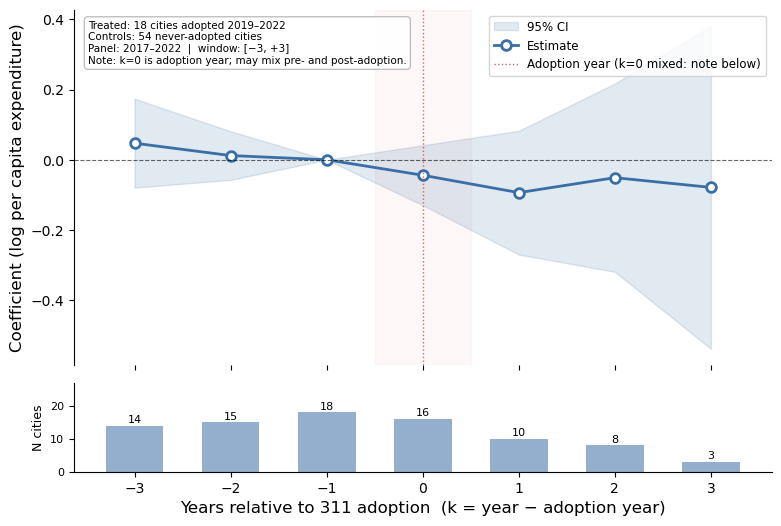

Saved fig_event_study.png


In [10]:
fig, (ax_main, ax_n) = plt.subplots(
    2, 1, figsize=(9, 6),
    gridspec_kw={'height_ratios': [4, 1], 'hspace': 0.08},
    sharex=True
)

bar_color  = '#3A6EA5'
line_color = '#1a1a1a'

# ── Main panel: coefficients ───────────────────────────────────────────────
ax_main.fill_between(tidy['k'], tidy['ci_low'], tidy['ci_high'],
                     alpha=0.15, color=bar_color, label='95% CI')
ax_main.plot(tidy['k'], tidy['estimate'],
             color=bar_color, linewidth=2, marker='o', markersize=7,
             markerfacecolor='white', markeredgewidth=2, label='Estimate')

ax_main.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.6)
ax_main.axvline(0, color='#cc4444', linewidth=1, linestyle=':', alpha=0.8,
                label='Adoption year (k=0 mixed: note below)')
ax_main.axvspan(-0.5, 0.5, alpha=0.04, color='#cc4444')   # subtle shade on k=0

ax_main.set_ylabel('Coefficient (log per capita expenditure)')
ax_main.set_xticks(sorted(tidy['k'].unique()))
ax_main.spines['bottom'].set_visible(False)
ax_main.legend(fontsize=8.5, loc='upper right')

# Sample note
ax_main.text(
    0.02, 0.97,
    f'Treated: {n_treat_es} cities adopted 2019–2022\n'
    f'Controls: {n_ctrl_es} never-adopted cities\n'
    f'Panel: 2017–2022  |  window: [−3, +3]\n'
    f'Note: k=0 is adoption year; may mix pre- and post-adoption.',
    transform=ax_main.transAxes, va='top', ha='left', fontsize=7.5,
    bbox=dict(boxstyle='round,pad=0.35', facecolor='white',
              edgecolor='#bbbbbb', alpha=0.92)
)

# ── Bottom panel: N per cell ───────────────────────────────────────────────
ax_n.bar(tidy['k'], tidy['n_cities'], color=bar_color, alpha=0.55, width=0.6)
for _, row in tidy.iterrows():
    if row['n_cities'] > 0:
        ax_n.text(row['k'], row['n_cities'] + 0.3, str(int(row['n_cities'])),
                  ha='center', va='bottom', fontsize=8)

ax_n.set_ylabel('N cities', fontsize=9)
ax_n.set_xlabel('Years relative to 311 adoption  (k = year − adoption year)')
ax_n.set_ylim(0, tidy['n_cities'].max() * 1.5)
ax_n.spines['top'].set_visible(False)
ax_n.spines['right'].set_visible(False)
ax_n.tick_params(axis='y', labelsize=8)

plt.savefig(FIGURES + 'fig_event_study.png')
plt.show()
print('Saved fig_event_study.png')

## Step 6 — Regression table

In [ ]:
# pyfixest etable for both specs
tab_tex = pf.etable(
    [fit_base, fit_late],
    type='tex',
    coef_fmt='b (se)',
    felabels={'GEOID': 'City FE', 'year': 'Year FE'},
    notes='Standard errors clustered at city level. '
          'Outcome: log total general expenditure per capita (Census Individual Unit Finance). '
          'Col.\\ 1: all treated cities (adopted 1996--2022) + never-adopted controls. '
          'Col.\\ 2: late adopters only (adopted 2012--2022) + never-adopted controls. '
          'Data: 2017--2022 only; cities adopting before 2017 are always-treated (no pre-period).'
)

# Fix the variable name: LaTeX treats underscores as subscript notation
tab_tex = tab_tex.replace('log_exp_pc', r'Log(exp.\ per capita)')

print(tab_tex)
with open(TABLES + 'tab_twfe.tex', 'w') as f:
    f.write(tab_tex)
print('\nSaved tab_twfe.tex')

In [12]:
# Save a clean CSV summary
def model_summary_row(fit, label):
    t = fit.tidy().reset_index()
    t.columns = ['term','estimate','se','tstat','pval','ci_low','ci_high']
    row = t[t['term'] == 'post311'].iloc[0]
    return {
        'spec':    label,
        'coef':    round(row['estimate'], 4),
        'se':      round(row['se'],       4),
        'pval':    round(row['pval'],     4),
        'ci_low':  round(row['ci_low'],   4),
        'ci_high': round(row['ci_high'],  4),
        'n_obs':   int(fit._N),
    }

summary = pd.DataFrame([
    model_summary_row(fit_base, 'All treated + controls (2017-2022)'),
    model_summary_row(fit_late, 'Late adopters (2012+) + controls (2017-2022)'),
])
summary.to_csv(TABLES + 'tab_twfe.csv', index=False)
print(summary.to_string(index=False))
print('\nSaved tab_twfe.csv')

                                        spec    coef     se   pval  ci_low  ci_high  n_obs
          All treated + controls (2017-2022) -0.0251 0.0343 0.4668 -0.0929   0.0428    867
Late adopters (2012+) + controls (2017-2022) -0.0202 0.0345 0.5594 -0.0885   0.0481    630

Saved tab_twfe.csv


In [13]:
# Final summary
print('=== QUESTION 3 COMPLETE ===')
print()
print('Panel coverage:')
print(f'  Years              : 2017–2022 (6 years)')
print(f'  Cities in panel    : {panel_reg["govid"].nunique()}')
print(f'  Treated (all)      : {panel_reg[panel_reg["adoption_status"]=="adopted"]["govid"].nunique()}')
print(f'  Treated (late ≥2012): {es_data[es_data["adoption_status"]=="adopted"]["govid"].nunique()}')
print(f'  Controls (never)   : {panel_reg[panel_reg["adoption_status"]=="not_adopted"]["govid"].nunique()}')
print()
print('Baseline TWFE (full sample):')
base_row = model_summary_row(fit_base, '')
print(f'  post311 coef = {base_row["coef"]:.4f}  SE = {base_row["se"]:.4f}  p = {base_row["pval"]:.3f}')
print()
print('Output files:')
for fp in [FIGURES+'fig_event_study.png', TABLES+'tab_twfe.tex', TABLES+'tab_twfe.csv']:
    print(f'  {fp}  {"OK" if Path(fp).exists() else "MISSING"}')

=== QUESTION 3 COMPLETE ===

Panel coverage:
  Years              : 2017–2022 (6 years)
  Cities in panel    : 153
  Treated (all)      : 99
  Treated (late ≥2012): 18
  Controls (never)   : 54

Baseline TWFE (full sample):
  post311 coef = -0.0251  SE = 0.0343  p = 0.467

Output files:
  ../results/figures/fig_event_study.png  OK
  ../results/tables/tab_twfe.tex  OK
  ../results/tables/tab_twfe.csv  OK
